# 🧠 Deep Learning from Scratch / Section 1
# The Perceptron: The Simplest Neural Model
---
**Course:** Deep Learning from Scratch · Pure Python + NumPy  
**Prerequisites:** Basic Python, high-school math  
**Goal:** Understand the perceptron / the single building block that started it all.

---
## 📌 Table of Contents
1. [Intuition](#intuition)
2. [Mathematical Formulation](#math)
3. [Implementation](#impl)
4. [Training Algorithm](#train)
5. [Experiment & Visualisation](#exp)


## 1. Intuition <a id="intuition"></a>

The **perceptron** (Rosenblatt, 1957) is inspired by a biological neuron:

- It receives several **numerical inputs** $x_1, x_2, \ldots, x_n$
- Multiplies each by a learned **weight** $w_i$ (how important is this input?)
- Sums everything up and adds a **bias** $b$
- **Fires** (outputs 1) if the total exceeds a threshold; otherwise stays silent (outputs 0)

```
    x₁ ──w₁──╮
    x₂ ──w₂──┼──►  z = Σwᵢxᵢ + b  ──►  step(z)  ──►  ŷ ∈ {0,1}
    x₃ ──w₃──╯
```

The perceptron is a **linear classifier** — it can only separate classes that are linearly separable (divisible by a straight line in 2D, a plane in 3D, etc.).


## 2. Mathematical Formulation <a id="math"></a>

### Weighted Sum
$$z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b$$

### Activation Function — Heaviside Step
$$\hat{y} = \text{step}(z) = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{otherwise} \end{cases}$$

### Decision Boundary
The boundary is the set of all $\mathbf{x}$ where $z = 0$:
$$\mathbf{w}^\top \mathbf{x} + b = 0$$
This is a **hyperplane** — a line in 2D, a plane in 3D.


## 3. Implementation <a id='impl'></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)


plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4d",
    "axes.labelcolor":  "#c8ccd8",
    "xtick.color":      "#c8ccd8",
    "ytick.color":      "#c8ccd8",
    "text.color":       "#c8ccd8",
    "grid.color":       "#2a2d3d",
    "grid.alpha":       0.5,
    "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#3a3d4d",
    "font.family":      "monospace",
})

ACCENT = "#7c83ff"
GREEN  = "#56d364"
ORANGE = "#ffa657"
PINK   = "#f778ba"
YELLOW = "#e3b341"

print(" Setup complete — NumPy", np.__version__)


 Setup complete — NumPy 2.0.2


In [7]:
# ── Perceptron class — every line explained ──────────────────────────────────

class Perceptron:


    def __init__(self, n_features: int, lr: float = 0.1, n_epochs: int = 100):
        self.w  = np.zeros(n_features)  # start weights at 0
        self.b  = 0.0                   # bias scalar
        self.lr = lr
        self.n_epochs = n_epochs
        self.errors_per_epoch = []      # track convergence


    @staticmethod
    def step(z: np.ndarray) -> np.ndarray:
        """Heaviside step: output 1 if z >= 0, else 0."""
        return np.where(z >= 0, 1, 0)


    def predict(self, X: np.ndarray) -> np.ndarray:

        z = X @ self.w + self.b      # shape (n_samples,)
        return self.step(z)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

print(" Perceptron class defined")


 Perceptron class defined


## 4. Training Algorithm <a id="train"></a>

### Perceptron Learning Rule
The perceptron updates **only when it makes a mistake**:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta \cdot (y - \hat{y}) \cdot \mathbf{x}$$
$$b \leftarrow b + \eta \cdot (y - \hat{y})$$

- If the prediction is **correct** → $y - \hat{y} = 0$ → **no update**
- If it predicted **0 but should be 1** → $y - \hat{y} = +1$ → push weights **toward** $\mathbf{x}$
- If it predicted **1 but should be 0** → $y - \hat{y} = -1$ → push weights **away from** $\mathbf{x}$

**Convergence theorem:** If the data are linearly separable, the algorithm is *guaranteed* to converge in a finite number of steps.


In [8]:
def fit(self, X: np.ndarray, y: np.ndarray):
    """
    Online (sample-by-sample) perceptron learning.
    Loops over every sample; updates only on misclassifications.
    """
    n_samples = X.shape[0]

    for epoch in range(self.n_epochs):
        errors = 0

        for i in range(n_samples):
            xi, yi = X[i], y[i]

           
            z_i  = np.dot(self.w, xi) + self.b
            yhat = self.step(z_i)

       
            delta = yi - yhat              

          
            if delta != 0:
                self.w += self.lr * delta * xi   
                self.b += self.lr * delta        
                errors += 1

        self.errors_per_epoch.append(errors)

        if errors == 0:
            print(f"   Converged at epoch {epoch+1}")
            break

    return self

# Attach method to class
Perceptron.fit = fit
print(" fit() method attached to Perceptron")


 fit() method attached to Perceptron


## 5. Experiment & Visualisation <a id='exp'></a>

In [9]:

n  = 100
X0 = np.random.randn(n // 2, 2) + np.array([-1.5, -1.5])   # class 0
X1 = np.random.randn(n // 2, 2) + np.array([ 1.5,  1.5])   # class 1
X_p = np.vstack([X0, X1])
y_p = np.hstack([np.zeros(n // 2), np.ones(n // 2)]).astype(int)

# Shuffle so training sees mixed classes
idx = np.random.permutation(n)
X_p, y_p = X_p[idx], y_p[idx]


perc = Perceptron(n_features=2, lr=0.1, n_epochs=200)
perc.fit(X_p, y_p)

print(f"  Final accuracy : {perc.accuracy(X_p, y_p)*100:.1f}%")
print(f"  Learned weights: w = {perc.w.round(4)},  b = {perc.b:.4f}")


   Converged at epoch 2
  Final accuracy : 100.0%
  Learned weights: w = [0.2602 0.1989],  b = 0.0000


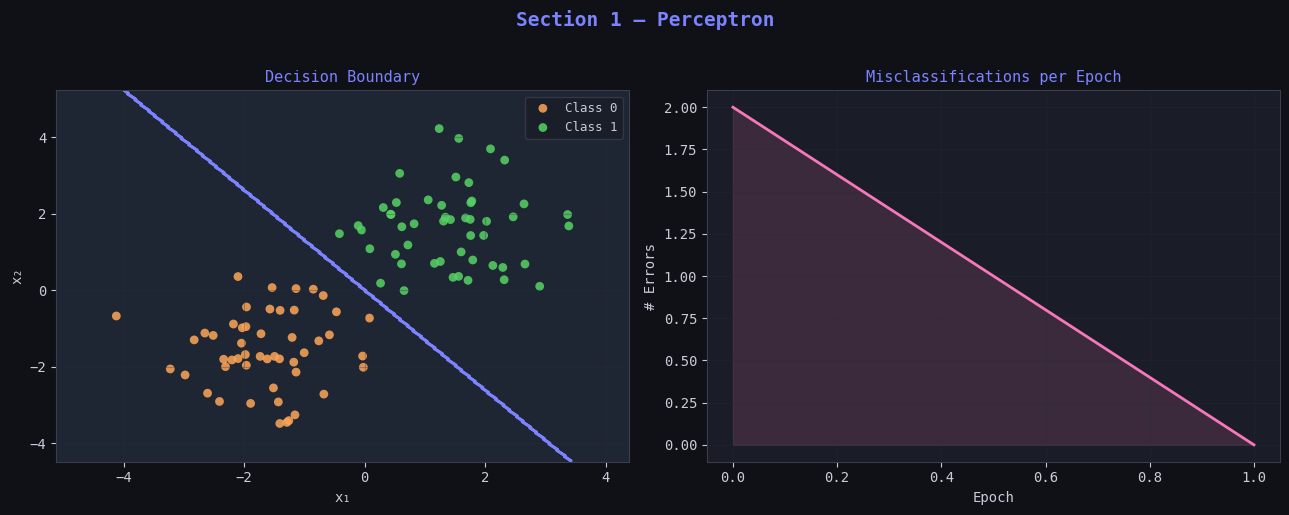

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Section 1 — Perceptron", fontsize=14, color=ACCENT,
             fontweight="bold", y=1.02)

# — Decision boundary —
ax = axes[0]
ax.set_facecolor("#1a1d27")
ax.set_title("Decision Boundary", color=ACCENT, fontsize=11)

x_min, x_max = X_p[:, 0].min() - 1, X_p[:, 0].max() + 1
y_min, y_max = X_p[:, 1].min() - 1, X_p[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = perc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.25, colors=["#2a3d5a", "#3d2a5a"])
ax.contour( xx, yy, Z, colors=[ACCENT], linewidths=1.5)
ax.scatter(X_p[y_p==0, 0], X_p[y_p==0, 1], c=ORANGE, s=40,
           label="Class 0", alpha=0.85, edgecolors="none")
ax.scatter(X_p[y_p==1, 0], X_p[y_p==1, 1], c=GREEN,  s=40,
           label="Class 1", alpha=0.85, edgecolors="none")
ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# — Misclassifications per epoch —
ax2 = axes[1]
ax2.set_facecolor("#1a1d27")
ax2.set_title("Misclassifications per Epoch", color=ACCENT, fontsize=11)
ax2.plot(perc.errors_per_epoch, color=PINK, linewidth=2)
ax2.fill_between(range(len(perc.errors_per_epoch)),
                 perc.errors_per_epoch, alpha=0.15, color=PINK)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("# Errors")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 🔑 Key Takeaways

| Concept | Value |
|---|---|
| **Model** | Linear classifier — hyperplane boundary |
| **Training** | Online update rule — one sample at a time |
| **Convergence** | Guaranteed *if* data are linearly separable |
| **Limitation** | Cannot solve XOR (not linearly separable) |

➡️ **Next:** Section 2 shows how stacking layers overcomes this limitation.
